# **Задание №7. Проектирование базы данных для информационной системы**

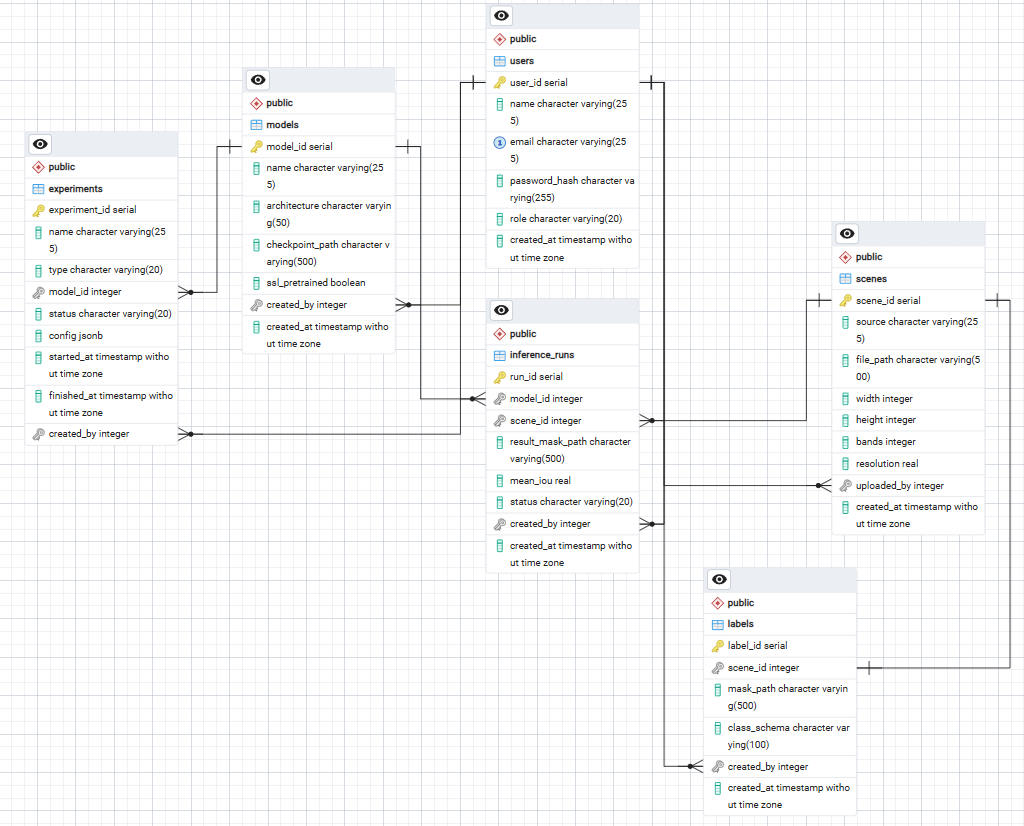

1. users — Пользователи
| Поле          | Тип                                  | Описание         |
| ------------- | ------------------------------------ | ---------------- |
| user_id       | INT, PK                              | Уникальный ID    |
| name          | VARCHAR                              | Имя пользователя |
| email         | VARCHAR, UNIQUE                      | Email для входа  |
| password_hash | VARCHAR                              | Хэш пароля       |
| role          | ENUM(ml_engineer, rs_analyst, admin) | Роль в системе   |
| created_at    | TIMESTAMP                            | Дата регистрации |
2. scenes — Сцены ДЗЗ
| Поле        | Тип             | Описание                     |
| ----------- | --------------- | ---------------------------- |
| scene_id    | INT, PK         | Уникальный ID                |
| source      | VARCHAR         | Источник сцены (миссия, URL) |
| file_path   | VARCHAR         | Путь к файлу (S3/локальный)  |
| width       | INT             | Ширина, пикселей             |
| height      | INT             | Высота, пикселей             |
| bands       | INT             | Число спектральных каналов   |
| resolution  | FLOAT           | Разрешение (м/пкс)           |
| uploaded_by | INT, FK → users | Кто загрузил                 |
| created_at  | TIMESTAMP       | Дата добавления              |
3. labels — Разметка сцен
| Поле         | Тип              | Описание                |
| ------------ | ---------------- | ----------------------- |
| label_id     | INT, PK          | Уникальный ID           |
| scene_id     | INT, FK → scenes | К какой сцене относится |
| mask_path    | VARCHAR          | Путь к файлу маски      |
| class_schema | VARCHAR          | Версия схемы классов    |
| created_by   | INT, FK → users  | Кто загрузил            |
| created_at   | TIMESTAMP        | Дата добавления         |

4. models — Обученные модели
| Поле            | Тип             | Описание                                 |
| --------------- | --------------- | ---------------------------------------- |
| model_id        | INT, PK         | Уникальный ID                            |
| name            | VARCHAR         | Название модели                          |
| architecture    | VARCHAR         | Тип архитектуры (hyenapixel, unet и др.) |
| checkpoint_path | VARCHAR         | Путь к файлу чекпоинта                   |
| ssl_pretrained  | BOOLEAN         | Использовалось ли SSL-предобучение       |
| created_by      | INT, FK → users | Кто создал                               |
| created_at      | TIMESTAMP       | Дата создания                            |
5. experiments — Задачи обучения
| Поле          | Тип                                         | Описание              |
| ------------- | ------------------------------------------- | --------------------- |
| experiment_id | INT, PK                                     | Уникальный ID         |
| name          | VARCHAR                                     | Название эксперимента |
| type          | ENUM(ssl, supervised)                       | Тип обучения          |
| model_id      | INT, FK → models                            | Обучаемая модель      |
| status        | ENUM(running, completed, failed, cancelled) | Статус                |
| config        | TEXT / JSON                                 | Гиперпараметры        |
| started_at    | TIMESTAMP                                   | Начало                |
| finished_at   | TIMESTAMP                                   | Завершение            |
| created_by    | INT, FK → users                             | Кто запустил          |
6. inference_runs — Запуски инференса
| Поле             | Тип                              | Описание                         |
| ---------------- | -------------------------------- | -------------------------------- |
| run_id           | INT, PK                          | Уникальный ID                    |
| model_id         | INT, FK → models                 | Какая модель использована        |
| scene_id         | INT, FK → scenes                 | На какой сцене                   |
| result_mask_path | VARCHAR                          | Путь к результирующей маске      |
| mean_iou         | FLOAT                            | Средний IoU (если есть разметка) |
| status           | ENUM(running, completed, failed) | Статус                           |
| created_by       | INT, FK → users                  | Кто запустил                     |
| created_at       | TIMESTAMP                        | Дата запуска                     |

Список сцен с информацией о пользователе и наличием разметки

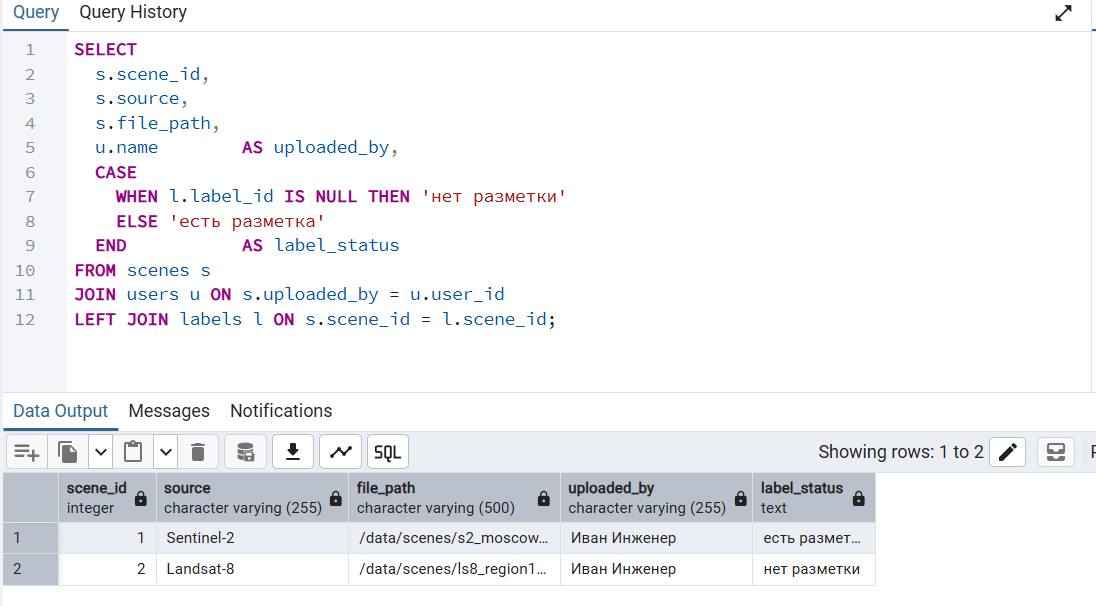

Сравнение качества инференса разных моделей на одной сцене

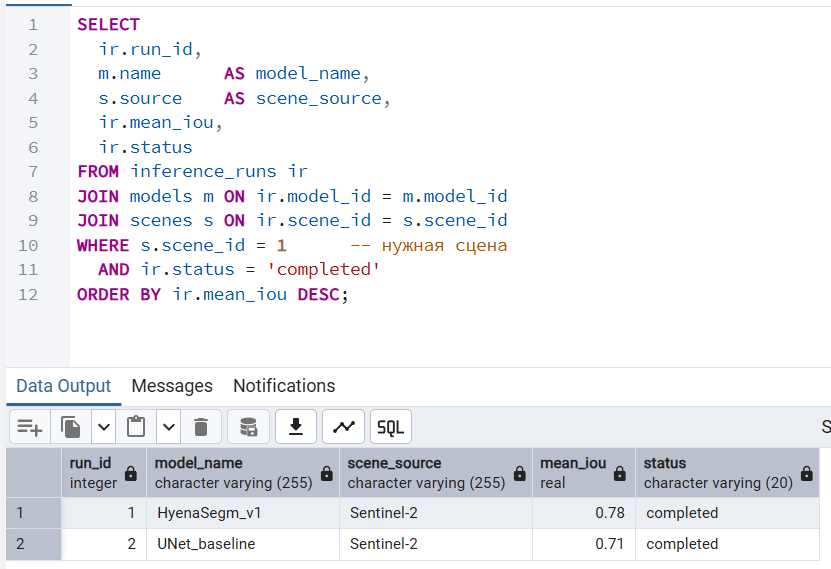

Все запуски по HyenaPixel‑модели

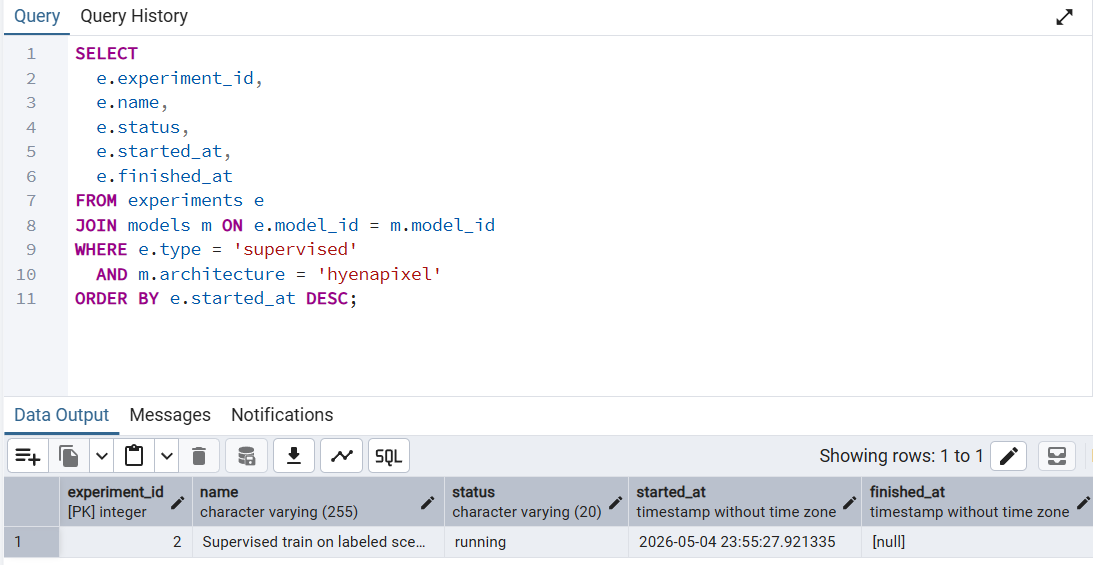